--- Task 2: Data Exploration ---
Data Shape: (99457, 10)

First 5 Rows:
  invoice_no customer_id  gender  age  category  quantity    price  \
0    I138884     C241288  Female   28  Clothing         5  1500.40   
1    I317333     C111565    Male   21     Shoes         3  1800.51   
2    I127801     C266599    Male   20  Clothing         1   300.08   
3    I173702     C988172  Female   66     Shoes         5  3000.85   
4    I337046     C189076  Female   53     Books         4    60.60   

  payment_method invoice_date   shopping_mall  
0    Credit Card     5/8/2022          Kanyon  
1     Debit Card   12/12/2021  Forum Istanbul  
2           Cash    9/11/2021       Metrocity  
3    Credit Card   16/05/2021    Metropol AVM  
4           Cash   24/10/2021          Kanyon  

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   i

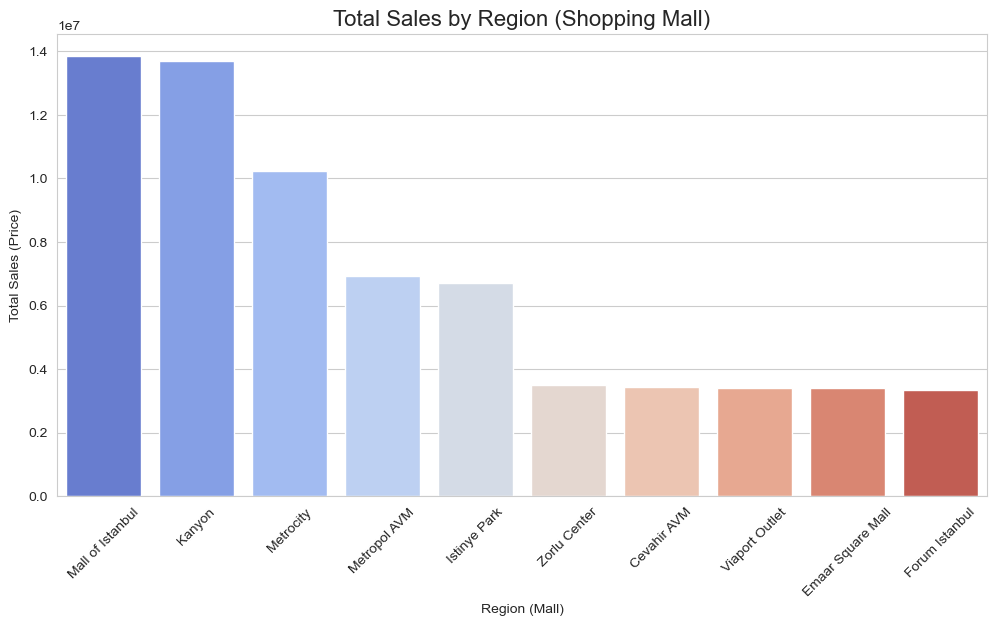

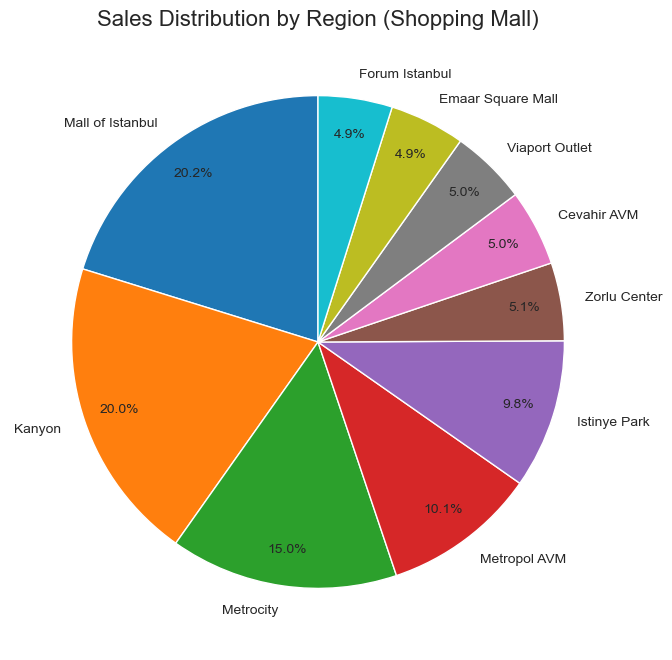


--- Task 6: Top Performing Regions ---
The top-performing region is: 'Mall of Istanbul' with $13,851,737.62 in sales.

--- Task 7: Sales by Region and Category ---
category              Books    Clothing  Cosmetics  Food & Beverage  \
shopping_mall                                                         
Cevahir AVM        11998.80  1554414.40   88394.84         11992.39   
Emaar Square Mall  11059.50  1511803.04   92379.52         11030.07   
Forum Istanbul     11453.40  1572119.12   95225.72         10836.56   
Istinye Park       20725.20  3050313.20  178741.36         23419.94   
Kanyon             44980.35  6155541.04  372242.30         45474.85   

category                Shoes  Souvenir  Technology       Toys  
shopping_mall                                                   
Cevahir AVM         884050.41   8304.84    819000.0   55516.16  
Emaar Square Mall   871446.84   8515.98    834750.0   49423.36  
Forum Istanbul      875648.03   9090.75    706650.0   55050.24  
Istinye Park

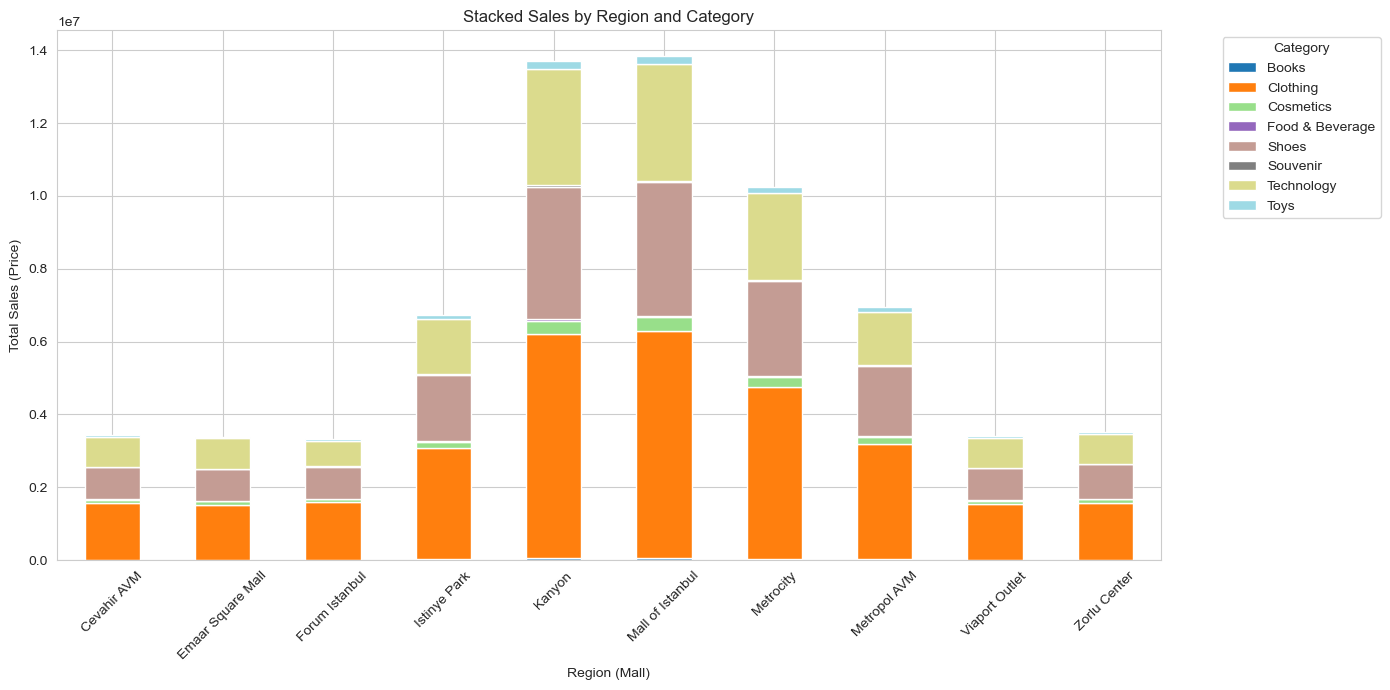

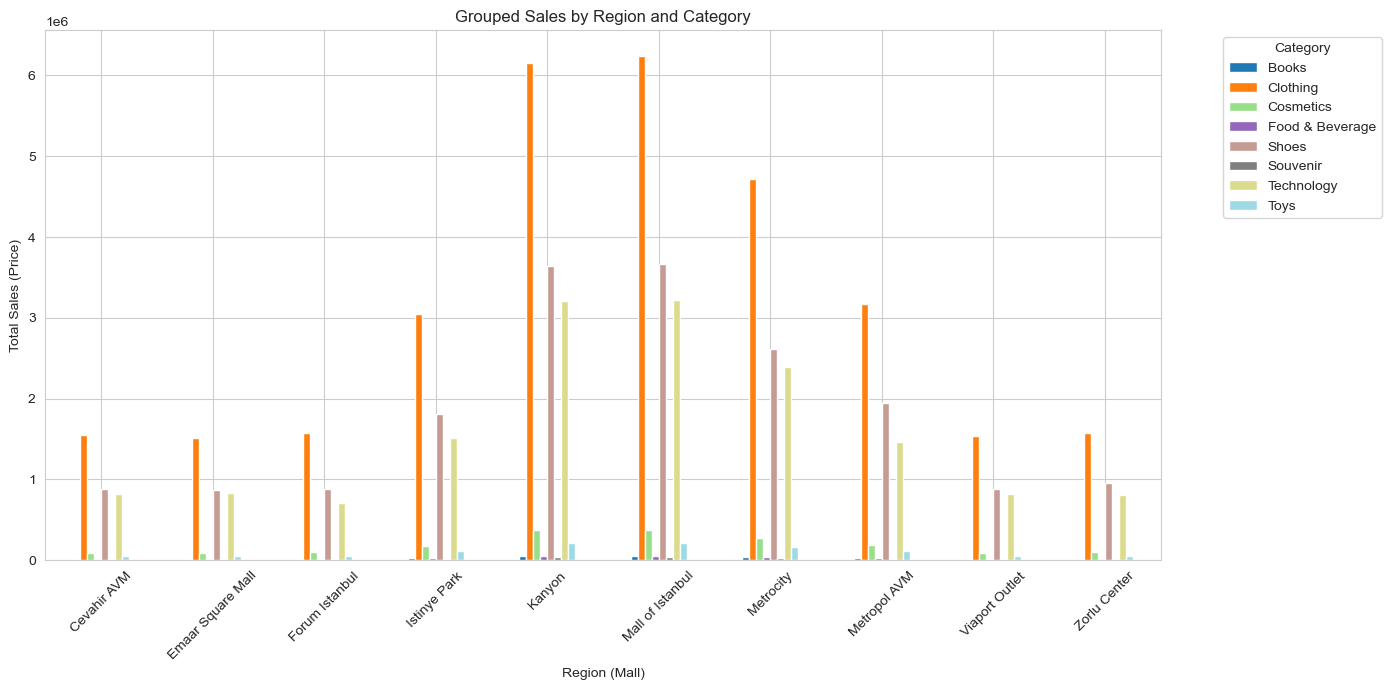


✅ All tasks complete.


In [2]:
#%% Step 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a nice style for the plots
sns.set_style("whitegrid")

#%% Task 1: Import the dataset
# We use the file from your Code 1, as it matches the problem
file_path = "customer_shopping_data.csv" 
df = pd.read_csv(file_path)

#%% Task 2: Explore the dataset
print("--- Task 2: Data Exploration ---")
print("Data Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())
print("\nColumn Info:")
df.info()

#%% Task 3: Identify relevant variables
# From the data, we will use:
# 'shopping_mall' as the REGION
# 'price' as the SALES AMOUNT
# 'category' as the PRODUCT CATEGORY
print("\n--- Task 3: Relevant Variables ---")
print("Region Column: 'shopping_mall'")
print("Sales Column: 'price'")
print("Category Column: 'category'")

#%% Task 4: Group by region and calculate total sales
print("\n--- Task 4: Total Sales by Region ---")
# We group by the 'shopping_mall' and sum the 'price'
# We sort it now to make Task 6 (finding top regions) easy
region_sales = df.groupby('shopping_mall')['price'].sum().sort_values(ascending=False)
print(region_sales)

#%% Task 5: Visualize sales distribution by region
print("\n--- Task 5: Visualizing Region Sales ---")

# --- Bar Plot (Better for comparing values) ---
plt.figure(figsize=(12, 6))
# Use .reset_index() to make 'shopping_mall' and 'price' columns for Seaborn
sns.barplot(data=region_sales.reset_index(), x='shopping_mall', y='price', palette='coolwarm')
plt.title('Total Sales by Region (Shopping Mall)', fontsize=16)
plt.xlabel('Region (Mall)')
plt.ylabel('Total Sales (Price)')
plt.xticks(rotation=45)
plt.show()

# --- Pie Chart (Better for seeing % distribution) ---
plt.figure(figsize=(10, 8))
plt.pie(region_sales, labels=region_sales.index, autopct='%1.1f%%', startangle=90, pctdistance=0.85)
plt.title('Sales Distribution by Region (Shopping Mall)', fontsize=16)
plt.show()

#%% Task 6: Identify the top-performing regions
print("\n--- Task 6: Top Performing Regions ---")
# Since we already sorted 'region_sales', the top region is the first one
top_region = region_sales.index[0]
top_sales = region_sales.iloc[0]
print(f"The top-performing region is: '{top_region}' with ${top_sales:,.2f} in sales.")

#%% Task 7: Group by region AND product category
print("\n--- Task 7: Sales by Region and Category ---")
# We can use pivot_table (like your code) to make this easy to plot
combined_pivot = df.pivot_table(index='shopping_mall', columns='category', values='price', aggfunc='sum')
print(combined_pivot.head())

#%% Task 8: Create stacked and grouped bar plots
print("\n--- Task 8: Visualizing Combined Sales ---")

# --- Stacked Bar Plot ---
# This shows the total sales for each mall, broken down by category
combined_pivot.plot(kind='bar', stacked=True, figsize=(14, 7), cmap='tab20')
plt.title('Stacked Sales by Region and Category')
plt.xlabel('Region (Mall)')
plt.ylabel('Total Sales (Price)')
plt.xticks(rotation=45)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- Grouped Bar Plot (like your code) ---
# This is better for comparing one category (e.g., 'Books') across all malls
combined_pivot.plot(kind='bar', stacked=False, figsize=(14, 7), cmap='tab20')
plt.title('Grouped Sales by Region and Category')
plt.xlabel('Region (Mall)')
plt.ylabel('Total Sales (Price)')
plt.xticks(rotation=45)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\n✅ All tasks complete.")